# CU44 — Capa XAI: Acciones Correctivas Prescriptivas

Este notebook ejecuta la metodología de explicabilidad del modelo Deep Neuro-Fuzzy para:

- Analizar comportamiento global del modelo.
- Explicar casos individuales combinando rama neuro-difusa y rama temporal (SHAP).
- Fusionar evidencia de ambas ramas en una interpretación única por caso.
- Generar acciones correctivas prescriptivas basadas en la evidencia interpretativa.
- Evaluar la consistencia del sistema de acciones por grupos TP/TN/FP/FN.

**Contenido del notebook:**
- **Librerías** — Importación de dependencias.
- **Interpretabilidad del modelo** — Funciones auxiliares y análisis de interpretabilidad:
  - *Global* — Visión general de las decisiones del modelo.
  - *Local orientada a acciones correctivas* — Firma neuro-difusa, firma temporal (SHAP) y fusión de ramas. Con ello, se lleva a cabo una validación/calibración interpretativa.
  - *Sistema de generación de acciones correctivas* — Lógica prescriptiva por evidencia interpretativa.
  - *Evaluación del sistema de acciones* — Métricas de calidad y consistencia.
- **Aplicación** — Ejecución final: interpretabilidad global, validación local y evaluación del sistema de acciones correctivas.

Una vez evaluado satisfactoriamente el sistema de generación de acciones correctivas, los parámetros utilizados deben escribirse en sus campos correspondientes en **config/config.yaml** (bloque xai) para incorporar dicho sistema al mecanismo de inferencia del repositorio.

**IMPORTANTE - Requesitos previos** 

Antes de ejecutar este notebook, deben haberse ejecutado estos pasos del pipeline:
- **python scripts/generate_dataset.py --xai**: comando que construye todos los conjuntos de datos necesarios. De lo contrario, saltará el error *FileNotFoundError* en cada paso.
- **python scripts/dataprocessing.py** y **python scripts/train.py**: comandos que, en el orden dispuesto, ejecutan el flujo de entrenamiento del modelo y dejan guardado los scalers de los datos de entrenamiento (scalers.pkl) y el archivo con los pesos del modelo (best_dnf_model.pt) en model/artifacts/.

# Librerías

In [ ]:
import os
import sys
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
from collections import Counter



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.chdir(ROOT)

from src.data_processing.load_data import load_raw_data
from src.data_processing.preprocess import create_sequences, stats_windows
from src.predict.predictor import load_model_artifacts
from src.predict.xai_predictor import (
    _prepare_inference_dataframe,
    _resolve_background_windows,
    _resolve_xai_runtime_config,
)
from src.xai import DNFLExplainer
from src.xai.corrective_actions import generate_corrective_actions
from src.utils.common import load_config
from src.utils.logging import get_logger

logger = get_logger(__name__)

# Interpretabilidad del modelo

## Constructor

In [2]:
def _normalize_path(path: str) -> str:
    if path is None:
        return path

    raw = str(path)
    root = Path(globals().get("ROOT", Path.cwd())).resolve()

    candidates = []

    p = Path(raw)
    if p.is_absolute():
        candidates.append(p)
    else:
        cleaned = raw.replace("\\", "/")
        while cleaned.startswith("../"):
            cleaned = cleaned[3:]
        if cleaned.startswith("./"):
            cleaned = cleaned[2:]

        candidates.extend([
            Path(raw),
            root / cleaned,
            Path.cwd().resolve() / cleaned,
        ])

    for candidate in candidates:
        if candidate.exists():
            resolved = candidate.resolve()
            try:
                return resolved.relative_to(root).as_posix()
            except ValueError:
                return str(resolved)

    return raw

def _resolve_sequence_feature_columns_local(df: pd.DataFrame, data_cfg: Dict[str, Any]) -> List[str]:
    target_column = str(data_cfg["target_column"]).lower()
    id_column = data_cfg.get("id_column")
    id_column = str(id_column).lower() if id_column else None
    timestamp_column = str(data_cfg.get("timestamp_column", "timestamp")).lower()

    excluded = {target_column, timestamp_column}
    if id_column:
        excluded.add(id_column)

    return [c for c in df.columns if c not in excluded]

def build_xai_context(
    config_path: str,
    dataset_path: str,
    action_config: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    config_path = _normalize_path(config_path)
    dataset_path = _normalize_path(dataset_path)
    
    config = load_config(config_path)
    data_cfg = config["data_processing"]

    xai_runtime_cfg = _resolve_xai_runtime_config(
        config,
        n_background=None,
        top_rules=None,
        top_variables=None,
        top_blocks=None,
    )
    if action_config is not None:
        xai_runtime_cfg["action_cfg"] = action_config

    df_input = load_raw_data(dataset_path)
    df_input.columns = df_input.columns.astype(str).str.strip().str.lower()

    target_column = str(data_cfg["target_column"]).lower()
    if target_column not in df_input.columns:
        raise ValueError(f"El dataset debe contener {target_column!r} para TP/TN/FP/FN.")

    df_input, validation_report = _prepare_inference_dataframe(
        df=df_input,
        config=config,
        data_cfg=data_cfg,
    )

    id_column = data_cfg.get("id_column")
    id_column = str(id_column).lower() if id_column else None
    timestamp_column = str(data_cfg.get("timestamp_column", "timestamp")).lower()
    overlap_beta = float(
        config.get("inference", {}).get(
            "solapamiento_beta",
            data_cfg["solapamiento_beta"],
        )
    )

    x_seq, y_seq, _ = create_sequences(
        df_input,
        target_column=target_column,
        seq_length=int(data_cfg["sequence_length"]),
        solapamiento_beta=overlap_beta,
        id_column=id_column,
        timestamp_column=timestamp_column,
        normal_tokens=data_cfg.get("normal_tokens"),
    )

    feature_names = _resolve_sequence_feature_columns_local(df_input, data_cfg)
    stats_creation = data_cfg.get("fuzzy_processing", {}).get("stats_creation")

    df_stats = stats_windows(
        x_seq,
        feature_names=feature_names,
        stats_creation=stats_creation,
    )

    model, _, scalers, threshold = load_model_artifacts(config)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    scaler_x = scalers["scaler_x"]
    scaler_num = scalers["scaler_num"]

    n_features = x_seq.shape[-1]
    x_scaled = scaler_x.transform(
        x_seq.reshape(-1, n_features)
    ).reshape(x_seq.shape)

    stats_scaled = pd.DataFrame(
        scaler_num.transform(df_stats),
        columns=df_stats.columns,
    )

    background_windows = _resolve_background_windows(
        scaler_x=scaler_x,
        data_cfg=data_cfg,
        config=config,
    )

    explainer = DNFLExplainer(
        model=model,
        feature_names_stats=df_stats.columns.tolist(),
        feature_names_original=feature_names,
        action_config=xai_runtime_cfg["action_cfg"],
        corrective_actions_cfg=xai_runtime_cfg["corrective_actions_cfg"],
        stats_creation=stats_creation,
        model_cfg=config.get("model", {}),
    )

    return {
        "config": config,
        "data_cfg": data_cfg,
        "xai_runtime_cfg": xai_runtime_cfg,
        "model": model,
        "device": device,
        "threshold": float(threshold),
        "explainer": explainer,
        "background_windows": background_windows,
        "X": x_scaled,
        "y": np.asarray(y_seq, dtype=int),
        "stats": stats_scaled,
        "df_input": df_input,
        "validation_report": validation_report,
    }

## Interpretabilidad Global

In [3]:
# =========================================================
# 1) Estructura de reglas
# =========================================================

from src.training import model


def analyze_rule_structure(model, feature_names: Optional[List[str]] = None) -> Dict[str, Any]:
    
    if not hasattr(model, "rule_layer") or not hasattr(model.rule_layer, "alpha"):
        raise AttributeError("El modelo no tiene model.rule_layer.alpha")
    with torch.no_grad():
        temperature = max(float(getattr(model.rule_layer, "temperature", 1.0)), 1e-8)
        alpha_probs = F.softmax(model.rule_layer.alpha / temperature, dim=-1).detach().cpu().numpy()

    R, F_dim, M = alpha_probs.shape
    if feature_names is None or len(feature_names) != F_dim:
        raise ValueError(f"feature_names debe tener longitud {F_dim}")
    feature_names = list(feature_names)

    eps = 1e-8
    entropy_rf = -(alpha_probs * np.log(np.clip(alpha_probs, eps, None))).sum(axis=-1)  # [R,F]
    dominant_mf = alpha_probs.argmax(axis=-1)  # [R,F]
    dominant_conf = alpha_probs.max(axis=-1)  # [R,F]

    mean_entropy_per_rule = entropy_rf.mean(axis=1)
    mean_conf_per_rule = dominant_conf.mean(axis=1)

    flat = alpha_probs.reshape(R, -1)
    norms = np.linalg.norm(flat, axis=1, keepdims=True)
    flat_norm = flat / np.clip(norms, 1e-8, None)
    similarity = flat_norm @ flat_norm.T

    return {
        "alpha_probs": alpha_probs,
        "dominant_mf": dominant_mf,
        "dominant_conf": dominant_conf,
        "entropy_rule_feature": entropy_rf,
        "mean_entropy_per_rule": mean_entropy_per_rule,
        "mean_conf_per_rule": mean_conf_per_rule,
        "rule_similarity": similarity,
        "feature_names": feature_names,
    }


def plot_rule_similarity_matrix(rule_structure: Dict[str, Any]):
    sim = rule_structure["rule_similarity"]

    fig, ax = plt.subplots(figsize=(8.5, 7.0))
    im = ax.imshow(sim, aspect="auto", cmap="magma")
    ax.set_title("Similitud estructural entre reglas", fontsize=15)
    ax.set_xlabel("Regla", fontsize=12)
    ax.set_ylabel("Regla", fontsize=12)
    ax.tick_params(axis="both", labelsize=10)

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Similitud coseno", fontsize=11)

    plt.tight_layout()
    plt.show()

def plot_rule_structure_summary(rule_structure: Dict[str, Any]):
    mean_entropy = rule_structure["mean_entropy_per_rule"]
    mean_conf = rule_structure["mean_conf_per_rule"]

    fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

    axes[0].hist(mean_entropy, bins=30, color="#5f8f7b", edgecolor="white", alpha=0.92)
    axes[0].set_title("Distribución de entropía media por regla", fontsize=15)
    axes[0].set_xlabel("Entropía media", fontsize=12)
    axes[0].set_ylabel("Frecuencia", fontsize=12)
    axes[0].tick_params(axis="both", labelsize=11)
    axes[0].grid(axis="y", alpha=0.18)

    axes[1].hist(mean_conf, bins=30, color="#d9924f", edgecolor="white", alpha=0.92)
    axes[1].set_title("Distribución de confianza media por regla", fontsize=15)
    axes[1].set_xlabel("Confianza media", fontsize=12)
    axes[1].set_ylabel("Frecuencia", fontsize=12)
    axes[1].tick_params(axis="both", labelsize=11)
    axes[1].grid(axis="y", alpha=0.18)

    plt.tight_layout()
    plt.show()

    plot_rule_similarity_matrix(rule_structure)

# =========================================================
# 2) Activaciones globales
# =========================================================

def collect_rule_activations(model, loader, device: Optional[torch.device] = None) -> Dict[str, Any]:
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    rule_acts_all = []
    y_binary_all = []
    logit_anomaly_dl_all = []
    logit_anomaly_fuzzy_all = []
    anomaly_score_all = []
    attention_all = []

    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                x_window, s_stats, y_class = batch
                s_stats = s_stats.to(device)
            else:
                x_window, y_class = batch
                s_stats = None

            x_window = x_window.to(device)
            y_class = y_class.to(device)
            out = model(x_window, s_stats)
            if not isinstance(out, dict):
                raise TypeError("El modelo debe devolver un dict.")

            if out.get("rule_activations") is None:
                continue

            rule_acts_all.append(out["rule_activations"].detach().cpu().numpy())

            y_binary = (y_class > 0).long()
            y_binary_all.append(y_binary.detach().cpu().numpy())

            logit_anomaly_dl_all.append(out["logit_anomaly_dl"].view(-1).detach().cpu().numpy())

            logit_anomaly_fuzzy_all.append(out["logit_anomaly_fuzzy"].view(-1).detach().cpu().numpy())
            anomaly_score_all.append(out["anomaly_score"].view(-1).detach().cpu().numpy())

            if out.get("attention_weights") is not None:
                attention_all.append(out["attention_weights"].detach().cpu().numpy())

    if len(rule_acts_all) == 0:
        raise ValueError("No se recogieron rule_activations del loader.")

    y_binary = np.concatenate(y_binary_all)
    logit_anomaly_fuzzy = np.concatenate(logit_anomaly_fuzzy_all) if len(logit_anomaly_fuzzy_all) > 0 else None
    logit_anomaly_dl = np.concatenate(logit_anomaly_dl_all) if len(logit_anomaly_dl_all) > 0 else None
    anomaly_score = np.concatenate(anomaly_score_all) if len(anomaly_score_all) > 0 else None

    return {
        "rule_activations": np.concatenate(rule_acts_all),
        "y_binary": y_binary,
        "logit_anomaly_fuzzy": logit_anomaly_fuzzy,
        "logit_anomaly_dl": logit_anomaly_dl,
        "anomaly_score": anomaly_score,
        "attention_weights": np.concatenate(attention_all) if len(attention_all) > 0 else None,
    }


def analyze_rule_usage_global(collected: Dict[str, Any], dead_rule_threshold: float = 1e-4) -> Dict[str, Any]:
    ra = collected["rule_activations"]
    y_bin = collected["y_binary"]

    mean_usage = ra.mean(axis=0)
    std_usage = ra.std(axis=0)
    dead_rules = np.where(mean_usage < dead_rule_threshold)[0]

    pos = ra[y_bin == 1] if np.any(y_bin == 1) else np.empty((0, ra.shape[1]))
    neg = ra[y_bin == 0] if np.any(y_bin == 0) else np.empty((0, ra.shape[1]))

    mean_pos = pos.mean(axis=0) if len(pos) > 0 else np.zeros(ra.shape[1])
    mean_neg = neg.mean(axis=0) if len(neg) > 0 else np.zeros(ra.shape[1])
    diff_bin = mean_pos - mean_neg
    top_bin_rules = np.argsort(np.abs(diff_bin))[::-1]

    return {
        "mean_usage": mean_usage,
        "std_usage": std_usage,
        "dead_rules": dead_rules,
        "mean_activation_pos": mean_pos,
        "mean_activation_neg": mean_neg,
        "diff_activation_binary": diff_bin,
        "top_discriminant_rules_binary": top_bin_rules,
    }


def plot_rule_usage_global(rule_usage, top_k=20, dead_rule_threshold=1e-4):
    mean_usage = np.asarray(rule_usage["mean_usage"], dtype=float)
    diff_bin = np.asarray(rule_usage["diff_activation_binary"], dtype=float)
    top_idx = rule_usage["top_discriminant_rules_binary"][:top_k]
    global_mean_usage = float(np.mean(mean_usage)) if mean_usage.size > 0 else 0.0

    n_rules = len(mean_usage)
    dead_mask = mean_usage < dead_rule_threshold
    
    colors = np.where(dead_mask, "#d55e5e", "#7aa6a1")

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))

    # Panel 1: activacion media ordenada + umbral
    axes[0].bar(np.arange(n_rules), mean_usage, color=colors, alpha=0.95)
    axes[0].margins(y=0.7)
    axes[0].axhline(dead_rule_threshold, color="#b22222", linestyle="--", linewidth=1.6, label=f"umbral={dead_rule_threshold:g}")
    axes[0].axhline(global_mean_usage, color="#ffd84d", linestyle=":", linewidth=2.0, label=f"media global={global_mean_usage:.4g}")
    axes[0].set_title(f"Activacion media por regla", fontsize=14)
    axes[0].set_xlabel("Índice de regla", fontsize=12)
    axes[0].set_ylabel("Activación media", fontsize=12)
    axes[0].grid(axis="y", alpha=0.2)
    axes[0].legend(fontsize=10)

    # Zoom en la cola baja para demostrar separacion sobre el umbral
    axes[0].set_yscale("symlog", linthresh=max(dead_rule_threshold, 1e-6))

    # Panel 2: top reglas discriminantes (igual que ya tenias)
    axes[1].barh(range(len(top_idx)), diff_bin[top_idx], color="#c96b3b", alpha=0.95)
    axes[1].set_yticks(range(len(top_idx)))
    axes[1].set_yticklabels([f"R{idx}" for idx in top_idx], fontsize=11)
    axes[1].set_title("Top reglas discriminantes", fontsize=14)
    axes[1].set_xlabel("Mean(pos) - Mean(neg)", fontsize=12)
    axes[1].grid(axis="x", alpha=0.2)

    plt.tight_layout()
    plt.show()

# =========================================================
# 2.b) AUC por regla 
# =========================================================

def analyze_rule_auc_for_binary(collected: Dict[str, Any]) -> Dict[str, Any]:
    ra = collected["rule_activations"]
    y_bin = collected["y_binary"]

    R = ra.shape[1]
    auc_per_rule = np.full(R, np.nan, dtype=float)

    if len(np.unique(y_bin)) < 2:
        return {"auc_per_rule": auc_per_rule, "top_rules_by_auc": np.arange(R)}

    for r in range(R):
        try:
            auc_per_rule[r] = float(roc_auc_score(y_bin, ra[:, r]))
        except Exception:
            auc_per_rule[r] = np.nan

    discriminative_power = np.abs(auc_per_rule - 0.5)
    top_rules = np.argsort(np.nan_to_num(discriminative_power, nan=-1.0))[::-1]

    return {
        "auc_per_rule": auc_per_rule,
        "discriminative_power": discriminative_power,
        "top_rules_by_auc": top_rules,
    }


def plot_rule_auc_for_binary(rule_auc_info: Dict[str, Any], top_k: int = 20):
    auc_per_rule = rule_auc_info["auc_per_rule"]
    top_idx = rule_auc_info["top_rules_by_auc"][:top_k]

    labels = [f"R{idx}" for idx in top_idx]
    values = [auc_per_rule[idx] for idx in top_idx]

    plt.figure(figsize=(10.5, max(4.5, 0.42 * len(labels))))
    plt.barh(range(len(labels)), values, color="#8f5d73", alpha=0.95)
    plt.yticks(range(len(labels)), labels, fontsize=11)
    plt.xticks(fontsize=11)
    plt.axvline(0.5, linestyle="--", color="#4f4f4f", linewidth=1.2)
    plt.xlabel("AUC individual", fontsize=12)
    plt.title("Top reglas por AUC individual", fontsize=15)
    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.18)
    plt.tight_layout()
    plt.show()



# =========================================================
# 3) Desacuerdo fuzzy vs DL 
# =========================================================

def analyze_branch_disagreement(
    collected: Dict[str, Any],
    threshold: float = 0.5,
) -> Dict[str, Any]:
    logit_fuzzy = collected.get("logit_anomaly_fuzzy", None)
    logit_dl = collected.get("logit_anomaly_dl", None)
    y_true = collected["y_binary"]

    if logit_fuzzy is None or logit_dl is None:
        return {"available": False, "reason": "Se requieren logit_anomaly_fuzzy y logit_anomaly_dl en collected."}

    prob_fuzzy = 1.0 / (1.0 + np.exp(-np.asarray(logit_fuzzy).reshape(-1)))
    prob_dl = 1.0 / (1.0 + np.exp(-np.asarray(logit_dl).reshape(-1)))

    pred_fuzzy = (prob_fuzzy >= threshold).astype(int)
    pred_dl = (prob_dl >= threshold).astype(int)

    agree_mask = pred_fuzzy == pred_dl
    fuzzy_correct = pred_fuzzy == y_true
    dl_correct = pred_dl == y_true

    fuzzy_only_correct = np.where(fuzzy_correct & (~dl_correct))[0]
    dl_only_correct = np.where(dl_correct & (~fuzzy_correct))[0]
    both_correct = np.where(fuzzy_correct & dl_correct)[0]
    both_wrong = np.where((~fuzzy_correct) & (~dl_correct))[0]

    confidence_gap = prob_fuzzy - prob_dl

    return {
        "available": True,
        "threshold": float(threshold),
        "prob_fuzzy": prob_fuzzy,
        "prob_dl": prob_dl,
        "pred_fuzzy": pred_fuzzy,
        "pred_dl": pred_dl,
        "agree_mask": agree_mask,
        "disagree_mask": ~agree_mask,
        "fuzzy_correct": fuzzy_correct,
        "dl_correct": dl_correct,
        "fuzzy_only_correct_idx": fuzzy_only_correct,
        "dl_only_correct_idx": dl_only_correct,
        "both_correct_idx": both_correct,
        "both_wrong_idx": both_wrong,
        "agreement_rate": float(agree_mask.mean()),
        "disagreement_rate": float((~agree_mask).mean()),
        "fuzzy_only_correct_rate": float(len(fuzzy_only_correct) / len(y_true)),
        "dl_only_correct_rate": float(len(dl_only_correct) / len(y_true)),
        "mean_confidence_gap": float(np.mean(confidence_gap)),
        "mean_abs_confidence_gap": float(np.mean(np.abs(confidence_gap))),
    }


# =========================================================
# 5) Pipeline maestro
# =========================================================

def run_global_interpretability_pipeline(
    path_dataset: str = "data/raw/interpretability_val.csv",
    path_config: str = "config/config.yaml",
    make_plots: bool = True,
    dead_rule_threshold: float = 1e-4,
    device: Optional[torch.device] = None,
    action_config: Optional[Dict[str, Any]] = None,
) -> None:

    path_config = _normalize_path(path_config)
    path_dataset = _normalize_path(path_dataset)

    context = build_xai_context(
        config_path=path_config,
        dataset_path=path_dataset,
        action_config=action_config,
    )

    if device is not None:
        device = torch.device(device)
        context["device"] = device
        context["model"] = context["model"].to(device).eval()

    config = context["config"]
    model = context["model"]
    device = context["device"]
    threshold = float(context["threshold"])

    seed = int(config.get("project", {}).get("seed", 42))
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    X = np.asarray(context["X"], dtype=np.float32)
    y = np.asarray(context["y"], dtype=np.int64).reshape(-1)
    stats_df = context["stats"]
    S = np.asarray(stats_df, dtype=np.float32)

    if len(X) != len(y) or len(X) != len(S):
        raise ValueError(f"Desajuste de tamaños: X={len(X)}, y={len(y)}, stats={len(S)}")

    dataset = torch.utils.data.TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(S, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )

    batch_size = int(config.get("training", {}).get("batch_size") or 128)
    test_loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    feature_names = list(stats_df.columns)

    rule_structure = analyze_rule_structure(model, feature_names=feature_names)
    collected = collect_rule_activations(model, test_loader, device=device)
    rule_usage = analyze_rule_usage_global(collected, dead_rule_threshold=dead_rule_threshold)
    rule_auc_info = analyze_rule_auc_for_binary(collected)
    disagreement_info = analyze_branch_disagreement(collected, threshold=threshold)

    print("\n" + "=" * 90)
    print("INTERPRETABILIDAD GLOBAL DNF")
    print("=" * 90)
    print(f"Dataset CSV: {path_dataset}")
    print(f"Config:      {path_config}")
    print(f"Threshold:   {threshold:.4f}")
    print(f"Reglas muertas: {len(rule_usage['dead_rules'])}")

    if disagreement_info.get("available", False):
        print("\n" + "-" * 50)
        print("Desacuerdo Entre Ramas\n")
        print(f"Agreement fuzzy vs DL: {disagreement_info['agreement_rate']:.4f}")
        print(f"Disagreement fuzzy vs DL: {disagreement_info['disagreement_rate']:.4f}")
        print(f"Fuzzy only correct rate: {disagreement_info['fuzzy_only_correct_rate']:.4f}")
        print(f"DL only correct rate: {disagreement_info['dl_only_correct_rate']:.4f}")
        print(f"Mean confidence gap: {disagreement_info['mean_confidence_gap']:.4f}")
        print(f"Mean abs confidence gap: {disagreement_info['mean_abs_confidence_gap']:.4f}")

    if make_plots:
        n_rules = int(rule_structure["alpha_probs"].shape[0])
        plot_rule_structure_summary(rule_structure)
        plot_rule_usage_global(rule_usage, top_k=min(20, n_rules), dead_rule_threshold=dead_rule_threshold)
        plot_rule_auc_for_binary(rule_auc_info, top_k=min(20, n_rules))

## Interpretabilidad local  orientada a acciones correctivas por tipo de fallo

### Validación / calibración interpretativa

In [4]:
# =========================================================
# Validación por tipo de grupo (TP/TN/FP/FN)
# =========================================================

# ---------------------------------------------------------
# Predicción final del modelo 
# ---------------------------------------------------------
def predict_model_on_split(
    model,
    split_data: Dict[str, Any],
    stats_df: pd.DataFrame,
    threshold: float = 0.5,
    batch_size: int = 128,
) -> Dict[str, Any]:
    model.eval()
    device = next(model.parameters()).device

    X = np.asarray(split_data["X"])
    y_raw = split_data.get("y", None)
    y = None if y_raw is None else np.asarray(y_raw).reshape(-1)
    S = stats_df

    if len(S) != len(X):
        raise ValueError(f"Desajuste len(stats)={len(S)} vs len(X)={len(X)}.")
    if y is not None and len(y) != len(X):
        raise ValueError(f"Desajuste len(y)={len(y)} vs len(X)={len(X)}.")

    n = len(X)
    probs, scores = [], []
    probs_dl, scores_dl = [], []
    probs_fuzzy, scores_fuzzy = [], []

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        x_batch = X[start:end]
        s_batch = S.iloc[start:end] 

        x_tensor = torch.tensor(np.asarray(x_batch), dtype=torch.float32, device=device)
        s_tensor = torch.tensor(np.asarray(s_batch), dtype=torch.float32, device=device)

        with torch.no_grad():
            out = model(x_tensor, s_stats=s_tensor)

        batch_scores = out["anomaly_score"].detach().cpu().numpy().reshape(-1)
        batch_probs = 1.0 / (1.0 + np.exp(-batch_scores))

        logit_dl = out.get("logit_anomaly_dl").detach().cpu().numpy().reshape(-1)
        logit_fuzzy = out.get("logit_anomaly_fuzzy").detach().cpu().numpy().reshape(-1)
        batch_probs_dl = 1.0 / (1.0 + np.exp(-logit_dl))
        batch_probs_fuzzy = 1.0 / (1.0 + np.exp(-logit_fuzzy))

        scores.extend(batch_scores.tolist())
        probs.extend(batch_probs.tolist())
        scores_dl.extend(logit_dl.tolist())
        probs_dl.extend(batch_probs_dl.tolist())
        scores_fuzzy.extend(logit_fuzzy.tolist())
        probs_fuzzy.extend(batch_probs_fuzzy.tolist())

    probs = np.asarray(probs)
    scores = np.asarray(scores)
    probs_dl = np.asarray(probs_dl)
    scores_dl = np.asarray(scores_dl)
    probs_fuzzy = np.asarray(probs_fuzzy)
    scores_fuzzy = np.asarray(scores_fuzzy)

    preds = (probs >= threshold).astype(int)
    preds_dl = (probs_dl >= threshold).astype(int)
    preds_fuzzy = (probs_fuzzy >= threshold).astype(int)

    return {
        "y_true": None if y is None else y,
        "y_pred": preds,
        "prob": probs,
        "score": scores,
        "prob_dl": probs_dl,
        "score_dl": scores_dl,
        "y_pred_dl": preds_dl,
        "prob_fuzzy": probs_fuzzy,
        "score_fuzzy": scores_fuzzy,
        "y_pred_fuzzy": preds_fuzzy,
    }


# ---------------------------------------------------------
# Índices por tipo de caso
# ---------------------------------------------------------
def build_confusion_groups(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> Dict[str, List[int]]:
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    groups = {
        "TP": np.where((y_true == 1) & (y_pred == 1))[0].tolist(),
        "TN": np.where((y_true == 0) & (y_pred == 0))[0].tolist(),
        "FP": np.where((y_true == 0) & (y_pred == 1))[0].tolist(),
        "FN": np.where((y_true == 1) & (y_pred == 0))[0].tolist(),
    }
    return groups


# ---------------------------------------------------------
# Muestreo por grupo
# ---------------------------------------------------------
def sample_group_indices(
    groups: Dict[str, List[int]],
    n_per_group: Optional[int] = 10,
    random_state: int = 42,
) -> Dict[str, List[int]]:
    rng = np.random.default_rng(random_state)
    sampled = {}

    for g, idxs in groups.items():
        if n_per_group is None or len(idxs) <= n_per_group:
            sampled[g] = list(idxs)
        else:
            chosen = rng.choice(np.asarray(idxs), size=n_per_group, replace=False)
            sampled[g] = sorted(chosen.tolist())

    return sampled


# ---------------------------------------------------------
# 5. Ejecutar explicabilidad completa en una muestra
# ---------------------------------------------------------

def run_full_interpretability_pipeline_for_sample(
    sample_idx: int,
    context: Dict[str, Any],
) -> Dict[str, Any]:
    threshold = float(context["threshold"])

    xai_result = context["explainer"].explain(
        x_window=context["X"][sample_idx],
        s_stats=np.asarray(context["stats"].iloc[sample_idx]),
        background_windows=context["background_windows"],
        anomaly_threshold=threshold,
        n_background=int(context["xai_runtime_cfg"]["n_background"]),
        top_rules=int(context["xai_runtime_cfg"]["top_rules"]),
        top_variables=int(context["xai_runtime_cfg"]["top_variables"]),
        top_blocks=int(context["xai_runtime_cfg"]["top_blocks"]),
        random_state=int(context["config"].get("project", {}).get("seed", 42)),
    )

    fuzzy_report = xai_result["explanation"]["fuzzy"]
    temporal_report = xai_result["explanation"]["temporal"]
    fusion_report = xai_result["explanation"]["fusion"]
    prediction = fusion_report["prediction"]

    true_class = int(context["y"][sample_idx])
    model_class = int(prediction["ensemble"]["predicted_class"])
    model_prob = float(prediction["ensemble"]["probability"])

    group_map = {(1, 1): "TP", (0, 0): "TN", (0, 1): "FP", (1, 0): "FN"}

    return {
        "sample_idx": int(sample_idx),
        "true_class": true_class,
        "model_class": model_class,
        "effective_group": group_map.get((true_class, model_class), "UNK"),
        "decision_threshold": threshold,
        "model_probability": model_prob,
        "model_probability_temporal": float(prediction["temporal"]["probability"]),
        "model_probability_fuzzy": float(prediction["fuzzy"]["probability"]),
        "decision_margin": abs(model_prob - threshold),
        "fuzzy_report": fuzzy_report,
        "temporal_report": temporal_report,
        "fusion_report": fusion_report,
        "corrective_actions": xai_result["corrective_actions"],
        "final_report": xai_result["final_report"],
    }


# ---------------------------------------------------------
# 6. Agregación simple de resultados por grupo
# ---------------------------------------------------------
def summarize_batch_results(
    batch_results: List[Dict[str, Any]],
    top_k: int = 10,
) -> Dict[str, Any]:
    if not batch_results:
        return {
            "n_cases": 0,
            "mean_model_prob": 0.0,
            "std_model_prob": 0.0,
            "mean_model_prob_temporal": 0.0,
            "std_model_prob_temporal": 0.0,
            "mean_model_prob_fuzzy": 0.0,
            "std_model_prob_fuzzy": 0.0,
            "mean_decision_threshold": 0.0,
            "std_decision_threshold": 0.0,
            "mean_decision_margin": 0.0,
            "std_decision_margin": 0.0,
            "mean_agreement": 0.0,
            "std_agreement": 0.0,
            "mean_support_ratio": 0.0,
            "std_support_ratio": 0.0,
            "dominant_fuzzy_variables": [],
            "dominant_fuzzy_variables_coverage_ratio": [],
            "dominant_temporal_variables": [],
            "dominant_temporal_variables_coverage_ratio": [],
            "dominant_shap_spans": [],
            "dominant_shap_spans_coverage_ratio": [],
            "shared_variables": [],
            "shared_variables_coverage_ratio": [],
        }

    def _update_presence(counter: Counter, names: List[str]) -> None:
        for name in names:
            counter[str(name)] += 1

    
    def _topk_ratio(counter_obj: Dict[str, float], k: int, n_cases: int) -> List[Tuple[str, float]]:
        denom = float(max(n_cases, 1))
        ranked = sorted(counter_obj.items(), key=lambda x: x[1], reverse=True)[:k]
        return [(name, float(val) / denom) for name, val in ranked]

    model_probs = []
    model_probs_temporal = []
    model_probs_fuzzy = []
    decision_margins = []
    agreements = []
    support_ratios = []

    fuzzy_var_counter = Counter()
    temporal_var_counter = Counter()
    shap_span_counter = Counter()
    shared_var_counter = Counter()

    for row in batch_results:
        rep_f = row["fuzzy_report"]
        rep_t = row["temporal_report"]
        rep_fu = row["fusion_report"]

        fuzzy_sig = rep_f["case_signature"]
        agreement = rep_fu.get("agreement", {})
        fusion_temporal = rep_fu.get("temporal", {})

        model_probs.append(float(row["model_probability"]))
        model_probs_temporal.append(float(row.get("model_probability_temporal", row["model_probability"])))
        model_probs_fuzzy.append(float(row.get("model_probability_fuzzy", row["model_probability"])))
        decision_margins.append(float(row["decision_margin"]))

        agreements.append(float(agreement.get("score", 0.0)))
        support_ratios.append(float(fuzzy_sig["support_ratio"]))

        fuzzy_var_pairs = [(str(var), float(score)) for var, score in fuzzy_sig.get("dominant_variables", [])[:5]]
        fuzzy_var_names = [name for name, _ in fuzzy_var_pairs]
        _update_presence(fuzzy_var_counter, fuzzy_var_names)

        temporal_var_pairs = [
            (str(var_row.get("feature", "unknown")), float(var_row.get("importance", 0.0)))
            for var_row in fusion_temporal.get("top_variables", [])[:5]
        ]
        temporal_var_names = [name for name, _ in temporal_var_pairs]
        temporal_var_weights = [score for _, score in temporal_var_pairs]
        _update_presence(temporal_var_counter, temporal_var_names)

        dominant_span = fusion_temporal.get("dominant_span_shap", rep_t.get("dominant_span_shap", "unknown"))
        dominant_span_name = str(dominant_span)
        _update_presence(shap_span_counter, [dominant_span_name])

        shared_variables = agreement.get("shared_variables", [])
        shared_var_names = [str(shared_var) for shared_var in shared_variables[:5]]
        _update_presence(shared_var_counter, shared_var_names)

    return {
        "n_cases": len(batch_results),
        "mean_model_prob": float(np.mean(model_probs)),
        "std_model_prob": float(np.std(model_probs)),
        "mean_model_prob_temporal": float(np.mean(model_probs_temporal)),
        "std_model_prob_temporal": float(np.std(model_probs_temporal)),
        "mean_model_prob_fuzzy": float(np.mean(model_probs_fuzzy)),
        "std_model_prob_fuzzy": float(np.std(model_probs_fuzzy)),
        "mean_decision_margin": float(np.mean(decision_margins)),
        "std_decision_margin": float(np.std(decision_margins)),
        "mean_agreement": float(np.mean(agreements)),
        "std_agreement": float(np.std(agreements)),
        "mean_support_ratio": float(np.mean(support_ratios)),
        "std_support_ratio": float(np.std(support_ratios)),
        "dominant_fuzzy_variables": fuzzy_var_counter.most_common(top_k),
        "dominant_fuzzy_variables_coverage_ratio": _topk_ratio(fuzzy_var_counter, top_k, len(batch_results)),
        "dominant_temporal_variables": temporal_var_counter.most_common(top_k),
        "dominant_temporal_variables_coverage_ratio": _topk_ratio(temporal_var_counter, top_k, len(batch_results)),
        "dominant_shap_spans": shap_span_counter.most_common(top_k),
        "dominant_shap_spans_coverage_ratio": _topk_ratio(shap_span_counter, top_k, len(batch_results)),
        "shared_variables": shared_var_counter.most_common(top_k),
        "shared_variables_coverage_ratio": _topk_ratio(shared_var_counter, top_k, len(batch_results)),
    }


# ---------------------------------------------------------
# 7. Validación por grupos de confusión (TP/TN/FP/FN)
# ---------------------------------------------------------
def validate_local_pipeline_by_confusion_group(
    path_config: str = "config/config.yaml",
    path_dataset: str = "data/raw/interpretability_val.csv",
    n_per_group: Optional[int] = 5,
    random_state: Optional[int] = None,
    verbose: bool = True,
    action_config: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:

    path_config = _normalize_path(path_config)
    path_dataset = _normalize_path(path_dataset)

    context = build_xai_context(
        config_path=path_config,
        dataset_path=path_dataset,
        action_config=action_config,
    )

    config = context["config"]
    threshold = float(context["threshold"])
    seed = int(random_state) if random_state is not None else int(config.get("project", {}).get("seed", 42))

    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    pred = predict_model_on_split(
        model=context["model"],
        split_data={"X": context["X"], "y": context["y"]},
        stats_df=context["stats"],
        threshold=threshold,
        batch_size=int(config.get("training", {}).get("batch_size") or 128),
    )

    if pred["y_true"] is None:
        raise ValueError("No hay y_true disponible para construir grupos TP/TN/FP/FN.")

    base_groups = build_confusion_groups(pred["y_true"], pred["y_pred"])
    if n_per_group == "all":
        sampled = {g: list(idxs) for g, idxs in base_groups.items()}
    else:
        sampled = sample_group_indices(base_groups, n_per_group=n_per_group, random_state=seed)

    if verbose:
        print("\nGrupos base:")
        for g in ["TP", "TN", "FP", "FN"]:
            print(f"  {g}: {len(base_groups.get(g, []))}")

    results = {
        "context": context,
        "predictions": pred,
        "base_groups": base_groups,
        "sampled_groups": sampled,
        "group_results": {g: [] for g in ["TP", "TN", "FP", "FN"]},
        "group_summaries": {},
        "decision_threshold": threshold,
        "random_state": seed,
        "paths": {
            "path_config": path_config,
            "path_dataset": path_dataset,
        },
    }

    for sampled_group_name, indices in sampled.items():
        if verbose:
            print(f"\nProcesando grupo {sampled_group_name}: {len(indices)} casos")

        for idx in indices:
            case = run_full_interpretability_pipeline_for_sample(
                sample_idx=int(idx),
                context=context,
            )
            case["sampled_from_group"] = sampled_group_name
            results["group_results"][sampled_group_name].append(case)

    results["evaluated_groups"] = {
        group_name: [row["sample_idx"] for row in rows]
        for group_name, rows in results["group_results"].items()
    }

    for group_name, rows in results["group_results"].items():
        results["group_summaries"][group_name] = summarize_batch_results(rows)

    return results

# ---------------------------------------------------------
# 8. Presentación por consola
# ---------------------------------------------------------
def print_group_validation_summary(validation_report: Dict[str, Any], top_k: int = 5) -> None:
    print("\n" + "=" * 100)
    print("VALIDACIÓN DE INTERPRETABILIDAD POR GRUPOS TP / TN / FP / FN")
    print("=" * 100)

    print(f"Threshold base de muestreo: {validation_report['decision_threshold']:.4f}")

    base_groups = validation_report.get("base_groups", {})
    print("\nTamaño total de grupos base:")
    for g in ["TP", "TN", "FP", "FN"]:
        print(f"  - {g}: {len(base_groups.get(g, []))}")

    print("\nResumen por grupos evaluados:")

    for g in ["TP", "TN", "FP", "FN"]:
        if g not in validation_report["group_summaries"]:
            continue

        s = validation_report["group_summaries"][g]
        print("\n" + "-" * 100)
        print(f"GRUPO {g} | n={s['n_cases']}")
        print("-" * 100)

        print(f"Prob. modelo media:     {s['mean_model_prob']:.4f} ± {s['std_model_prob']:.4f}")
        print(f"Prob. rama DL media:    {s['mean_model_prob_temporal']:.4f} ± {s['std_model_prob_temporal']:.4f}")
        print(f"Prob. rama NF media:    {s['mean_model_prob_fuzzy']:.4f} ± {s['std_model_prob_fuzzy']:.4f}")
        print(f"Margen al threshold:    {s['mean_decision_margin']:.4f} ± {s['std_decision_margin']:.4f}")
        print(f"Agreement medio:        {s['mean_agreement']:.4f} ± {s['std_agreement']:.4f}")
        print(f"Support ratio medio:    {s['mean_support_ratio']:.4f} ± {s['std_support_ratio']:.4f}")

        print("Variables dominantes de la rama neuro-difusa:")
        print("  Cobertura normalizada (conteo/n):")
        for name, r in s.get("dominant_fuzzy_variables_coverage_ratio", [])[:top_k]:
            print(f"    - {name}: {r:.4f}")

        print("Variables dominantes de la rama temporal SHAP/LSTM:")
        print("  Cobertura normalizada (conteo/n):")
        for name, r in s.get("dominant_temporal_variables_coverage_ratio", [])[:top_k]:
            print(f"    - {name}: {r:.4f}")

        print("Tramo dominante SHAP:")
        print("  Cobertura normalizada (conteo/n):")
        for name, r in s.get("dominant_shap_spans_coverage_ratio", [])[:top_k]:
            print(f"    - {name}: {r:.4f}")

        print("Variables dominantes compartidas:")
        print("  Cobertura normalizada (conteo/n):")
        for name, r in s.get("shared_variables_coverage_ratio", [])[:top_k]:
            print(f"    - {name}: {r:.4f}")

### Coherencia XAI

In [5]:
# =========================================================
# Coherencia XAI vs variables inyectadas
# =========================================================

FAULT_EXPECTED_VARIABLES = {
    "AISLAMIENTO_DEGRADADO": {
        "potencia_kw", "temp_zona3", "temp_zona1",
        "temp_salida_gases", "humedad_relativa",
    },
    "RESISTENCIA_DEGRADADA": {
        "potencia_kw", "temp_zona1", "temp_zona2",
        "temp_zona3", "temp_salida_gases", "humedad_relativa",
    },
    "REFRACTARIO_EROSIONADO": {
        "temp_zona2", "temp_zona1", "temp_zona3",
        "presion_camara", "presion_ventilacion", "humedad_relativa",
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA1_FROZEN": {
        "temp_zona1", "potencia_kw", "temp_salida_gases",
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA2_FROZEN": {
        "temp_zona2", "potencia_kw", "temp_salida_gases",
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA3_FROZEN": {
        "temp_zona3", "potencia_kw", "temp_salida_gases",
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA1_SPIKE": {
        "temp_zona1"
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA2_SPIKE": {
        "temp_zona2"
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA3_SPIKE": {
        "temp_zona3"
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA1_DRIFT": {
        "temp_zona1", "potencia_kw"
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA2_DRIFT": {
        "temp_zona2", "potencia_kw"
    },
    "SENSOR_DESCALIBRADO_TEMP_ZONA3_DRIFT": {
        "temp_zona3", "potencia_kw"
    },
    "VALVULA_OBSTRUIDA": {
        "flujo_gas", "posicion_valvula", "temp_zona1",
        "temp_zona2", "temp_zona3", "presion_ventilacion",
        "presion_camara", "humedad_relativa",
    },
    "VENTILADOR_DEFECTUOSO": {
        "velocidad_ventilador", "presion_camara", "temp_zona1",
        "temp_zona2", "temp_zona3", "temp_salida_gases",
        "temp_ambiente", "humedad_relativa",
    },
}


def _is_normal_fault_label(value) -> bool:
    text = str(value).strip().upper()
    return text in {"", "0", "NORMAL", "NONE", "OK", "NO FALLO", "SIN FALLO", "SIN FALLA"}


def build_window_injected_truth(df: pd.DataFrame, data_cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    """Construye verdad XAI por ventana"""
    target_column = str(data_cfg.get("target_column", "fault_name")).lower()
    id_column = data_cfg.get("id_column")
    id_column = str(id_column).lower() if id_column else None
    timestamp_column = str(data_cfg.get("timestamp_column", "timestamp")).lower()
    seq_length = int(data_cfg["sequence_length"])
    overlap_beta = float(data_cfg.get("solapamiento_beta", 0.0))
    step = max(1, int(seq_length * (1 - overlap_beta)))
    normal_tokens = data_cfg.get("normal_tokens")
    normal_tokens = [] if normal_tokens is None else [str(t).strip().lower() for t in normal_tokens]

    df_local = df.copy()
    df_local.columns = df_local.columns.astype(str).str.strip().str.lower()
    if target_column not in df_local.columns:
        raise ValueError(f"La columna objetivo {target_column!r} no existe en el DataFrame.")

    if timestamp_column in df_local.columns:
        sort_cols = [id_column, timestamp_column] if id_column in df_local.columns else [timestamp_column]
        df_local = df_local.sort_values(sort_cols).reset_index(drop=True)
    else:
        df_local = df_local.reset_index(drop=True)

    def _window_anomaly_mask(labels) -> np.ndarray:
        series = pd.Series(labels)
        numeric_values = pd.to_numeric(series, errors="coerce")
        if numeric_values.notna().all():
            return numeric_values.astype(float).to_numpy() > 0

        text_values = (
            series.astype(str)
            .str.strip()
            .str.lower()
            .replace({"nan": "", "none": ""})
        )
        normal_mask = text_values.isin(normal_tokens) | (text_values == "")
        return (~normal_mask).to_numpy()

    def _one_window(labels) -> Dict[str, Any]:
        labels = np.asarray(labels)
        anomaly_mask = _window_anomaly_mask(labels)
        fault_fraction = float(anomaly_mask.mean()) if len(labels) else 0.0
        window_is_anomaly = bool(fault_fraction >= 0.5)
        all_fault_names = sorted({
            str(label).strip().upper()
            for label, is_anomaly in zip(labels, anomaly_mask)
            if bool(is_anomaly) and not _is_normal_fault_label(label)
        })
        fault_names = all_fault_names if window_is_anomaly else []
        expected_vars = sorted(set().union(*[
            FAULT_EXPECTED_VARIABLES.get(name, set())
            for name in fault_names
        ])) if fault_names else []
        return {
            "fault_names": fault_names,
            "all_fault_names": all_fault_names,
            "fault_fraction": fault_fraction,
            "window_is_anomaly": window_is_anomaly,
            "expected_variables": expected_vars,
            "is_fault_window": bool(expected_vars),
        }

    out = []
    if id_column and id_column in df_local.columns:
        for _, g in df_local.groupby(id_column, sort=False):
            labels = g[target_column].to_numpy()
            for i in range(0, len(g) - seq_length + 1, step):
                out.append(_one_window(labels[i:i + seq_length]))
    else:
        labels = df_local[target_column].to_numpy()
        for i in range(0, len(df_local) - seq_length + 1, step):
            out.append(_one_window(labels[i:i + seq_length]))

    return out

In [6]:
COHERENCE_SOURCES = ["Neuro-difusa", "LSTM-SHAP"]
COHERENCE_METRICS = ["Jaccard", "MRR"]


def _coherence_metric_columns() -> List[str]:
    return [
        f"{source}_{metric}"
        for source in COHERENCE_SOURCES
        for metric in COHERENCE_METRICS
    ]

def _ordered_unique(values) -> List[str]:
    seen, out = set(), []
    for value in values:
        v = str(value).strip()
        if v and v not in seen:
            seen.add(v)
            out.append(v)
    return out

def _mean_with_n_cases(
    df: pd.DataFrame,
    group_cols: List[str],
    metric_cols: List[str],
) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["N_cases"] + metric_cols)

    grouped = df.groupby(group_cols, dropna=False)
    out = grouped[metric_cols].mean(numeric_only=True)
    out.insert(0, "N_cases", grouped.size().astype(int))
    return out

def _xai_top_variables(case: Dict[str, Any], source: str, k: int = 5) -> List[str]:
    if source == "Neuro-difusa":
        pairs = case.get("fuzzy_report", {}).get("case_signature", {}).get("dominant_variables", [])
        return _ordered_unique([name for name, _ in pairs])[:k]

    if source == "LSTM-SHAP":
        rows = case.get("temporal_report", {}).get("top_variables", [])
        return _ordered_unique([row.get("feature") for row in rows])[:k]

    raise ValueError(f"source no soportado: {source}")

def _coherence_scores(
    predicted_vars: List[str],
    expected_vars: List[str],
) -> Dict[str, float]:
    pred = list(_ordered_unique(predicted_vars))
    pred_set = set(pred)
    truth = set(expected_vars)

    if not truth:
        return {"Jaccard": np.nan, "MRR": np.nan}

    inter = pred_set & truth
    union = pred_set | truth

    ranks = [
        rank
        for rank, name in enumerate(pred, start=1)
        if name in truth
    ]
    best_rank = min(ranks) if ranks else None
    mrr = 1.0 / float(best_rank) if best_rank is not None else 0.0

    return {
        "Jaccard": float(len(inter) / len(union)) if union else np.nan,
        "MRR": float(mrr),
    }

def compute_xai_coherence(
    case: Dict[str, Any],
    window_truth: List[Dict[str, Any]],
) -> Dict[str, Any]:
    sample_idx = int(case["sample_idx"])
    truth_row = window_truth[sample_idx]

    expected = list(truth_row.get("expected_variables", []))
    fault_names = list(truth_row.get("fault_names", []))
    m = int(len(expected))

    out = {
        "sample_idx": sample_idx,
        "fault_names": fault_names,
        "fault_key": "+".join(fault_names) if fault_names else None,
        "n_faults_in_window": int(len(fault_names)),
        "expected_variables": expected,
        "expected_size": m,
        "fault_fraction": float(truth_row.get("fault_fraction", np.nan)),
        "window_is_anomaly": bool(truth_row.get("window_is_anomaly", False)),
    }

    if m <= 0:
        for source in COHERENCE_SOURCES:
            for metric in COHERENCE_METRICS:
                out[f"{source}_{metric}"] = np.nan
        return out

    for source in COHERENCE_SOURCES:
        pred = _xai_top_variables(case, source=source, k=m)
        scores = _coherence_scores(
            predicted_vars=pred,
            expected_vars=expected,
        )

        out[f"{source}_top_m"] = pred
        for metric, value in scores.items():
            out[f"{source}_{metric}"] = value

    return out

In [7]:
def _fault_display_key(fault_key: Optional[str]) -> Optional[str]:
    if fault_key is None or pd.isna(fault_key):
        return fault_key

    key = str(fault_key)
    if key.startswith("SENSOR_DESCALIBRADO_"):
        for mode in ["FROZEN", "SPIKE", "DRIFT"]:
            if key.endswith(f"_{mode}"):
                return f"SENSOR_DESCALIBRADO_{mode}"

    return key


def _rename_fault_display_index(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df

    rename_map = {
        "Fault_display_key": "Fault_key"
        }
    if isinstance(df.index, pd.MultiIndex):
        df.index = df.index.rename([
            rename_map.get(name, name)
            for name in df.index.names
        ])
    else:
        df.index = df.index.rename(rename_map.get(df.index.name, df.index.name))

    return df


def xai_coherence_rows_to_dataframe(
    validation_report: Dict[str, Any],
) -> pd.DataFrame:
    rows = []

    for group_name, cases in validation_report.get("group_results", {}).items():
        for case in cases:
            coh = case.get("xai_coherence")
            if not coh:
                continue

            fault_key = coh.get("fault_key")
            row = {
                "Group": group_name,
                "sample_idx": coh["sample_idx"],
                "Fault_key": fault_key,
                "Fault_display_key": _fault_display_key(fault_key),
                "fault_names": ",".join(coh.get("fault_names", [])),
                "n_faults_in_window": coh.get("n_faults_in_window", 0),
                "Affected_variables_count": coh.get("expected_size", 0),
                "fault_fraction": coh.get("fault_fraction", np.nan),
                "expected_variables": ",".join(coh.get("expected_variables", [])),
            }

            for source in COHERENCE_SOURCES:
                for metric in COHERENCE_METRICS:
                    key = f"{source}_{metric}"
                    row[key] = coh.get(key, np.nan)

            rows.append(row)

    return pd.DataFrame(rows)


def summarize_xai_coherence(validation_report: Dict[str, Any]) -> pd.DataFrame:
    df = xai_coherence_rows_to_dataframe(validation_report)
    metric_cols = _coherence_metric_columns()

    if df.empty:
        return pd.DataFrame(columns=["N_cases"] + metric_cols)

    return _mean_with_n_cases(df, ["Group"], metric_cols)


def evaluate_xai_coherence_by_confusion_group(
    path_config: str = "config/config.yaml",
    path_dataset: str = "data/raw/interpretability_val.csv",
    n_per_group: Optional[int] = 100,
    random_state: Optional[int] = None,
    verbose: bool = True,
    action_config: Optional[Dict[str, Any]] = None,
    evaluate_only_fault_windows: bool = True,
    include_empty_groups: bool = False,
) -> Dict[str, Any]:
    path_config = _normalize_path(path_config)
    path_dataset = _normalize_path(path_dataset)

    context = build_xai_context(
        config_path=path_config,
        dataset_path=path_dataset,
        action_config=action_config,
    )

    config = context["config"]
    threshold = float(context["threshold"])
    seed = int(random_state) if random_state is not None else int(config.get("project", {}).get("seed", 42))

    pred = predict_model_on_split(
        model=context["model"],
        split_data={"X": context["X"], "y": context["y"]},
        stats_df=context["stats"],
        threshold=threshold,
        batch_size=int(config.get("training", {}).get("batch_size") or 128),
    )

    if pred["y_true"] is None:
        raise ValueError("No hay y_true disponible para construir grupos TP/TN/FP/FN.")

    truth_data_cfg = dict(context["data_cfg"])
    truth_data_cfg["solapamiento_beta"] = float(
        config.get("inference", {}).get(
            "solapamiento_beta",
            truth_data_cfg.get("solapamiento_beta", 0.0),
        )
    )

    window_truth = build_window_injected_truth(
        df=context["df_input"],
        data_cfg=truth_data_cfg,
    )

    if len(window_truth) != len(context["X"]):
        raise ValueError(
            f"Desajuste entre window_truth={len(window_truth)} y X={len(context['X'])}."
        )

    base_groups = build_confusion_groups(pred["y_true"], pred["y_pred"])

    evaluable_mask = np.asarray([
        bool(row.get("expected_variables"))
        for row in window_truth
    ])

    if evaluate_only_fault_windows:
        candidate_groups = {
            g: [int(idx) for idx in idxs if evaluable_mask[int(idx)]]
            for g, idxs in base_groups.items()
        }
    else:
        candidate_groups = {
            g: [int(idx) for idx in idxs]
            for g, idxs in base_groups.items()
        }

    if n_per_group == "all":
        sampled = {g: list(idxs) for g, idxs in candidate_groups.items()}
    else:
        sampled = sample_group_indices(
            candidate_groups,
            n_per_group=n_per_group,
            random_state=seed,
        )

    if not include_empty_groups:
        sampled = {
            g: idxs
            for g, idxs in sampled.items()
            if len(idxs) > 0
        }

    if verbose:
        print("\n" + "=" * 100)
        print("COHERENCIA XAI VS VARIABLES INYECTADAS")
        print("=" * 100)
        print(f"Dataset: {path_dataset}")
        print(f"Threshold: {threshold:.4f}")
        print("\nGrupos base:")
        for g in ["TP", "TN", "FP", "FN"]:
            print(f"  {g}: {len(base_groups.get(g, []))}")

        print("\nVentanas evaluables para coherencia XAI:")
        for g in ["TP", "FN"]:
            print(f"  {g}: {len(candidate_groups.get(g, []))}")

    output_groups = ["TP", "TN", "FP", "FN"] if include_empty_groups else list(sampled.keys())

    results = {
        "context": context,
        "predictions": pred,
        "base_groups": base_groups,
        "candidate_groups": candidate_groups,
        "sampled_groups": sampled,
        "group_results": {g: [] for g in output_groups},
        "skipped_groups": {
            g: {
                "base_n": int(len(base_groups.get(g, []))),
                "evaluable_n": int(len(candidate_groups.get(g, []))),
                "reason": "sin expected_variables bajo la regla de create_sequences"
            }
            for g in ["TP", "TN", "FP", "FN"]
            if len(base_groups.get(g, [])) > 0 and len(candidate_groups.get(g, [])) == 0
        },
        "decision_threshold": threshold,
        "n_per_group": n_per_group,
        "random_state": seed,
        "evaluate_only_fault_windows": bool(evaluate_only_fault_windows),
        "paths": {
            "path_config":path_config,
            "path_dataset": path_dataset,
        },
    }

    for sampled_group_name, indices in sampled.items():
        if verbose:
            print(f"\nProcesando coherencia {sampled_group_name}: {len(indices)} casos")

        for idx in indices:
            case = run_full_interpretability_pipeline_for_sample(
                sample_idx=int(idx),
                context=context,
            )
            results["group_results"][sampled_group_name].append({
                "sample_idx": int(idx),
                "sampled_from_group": sampled_group_name,
                "effective_group": case.get("effective_group", sampled_group_name),
                "xai_coherence": compute_xai_coherence(
                    case=case,
                    window_truth=window_truth,
                ),
            })

    results["evaluated_groups"] = {
        group_name: [row["sample_idx"] for row in rows]
        for group_name, rows in results["group_results"].items()
    }

    coherence_df = xai_coherence_rows_to_dataframe(results)
    metric_cols = _coherence_metric_columns()

    results["coherence_dataset"] = coherence_df
    results["coherence_summary"] = summarize_xai_coherence(results)

    if coherence_df.empty:
        results["coherence_by_fault_raw"] = pd.DataFrame(columns=["N_cases"] + metric_cols)
        results["coherence_macro_by_fault_only_raw"] = pd.DataFrame(columns=["N_cases"] + metric_cols)
        results["coherence_by_fault"] = pd.DataFrame(columns=["N_cases"] + metric_cols)
        results["coherence_macro_by_fault_only"] = pd.DataFrame(columns=["N_cases"] + metric_cols)
        results["coherence_macro_by_group"] = pd.DataFrame(columns=["N_cases", "N_fault_types"] + metric_cols)
    else:
        results["coherence_by_fault_raw"] = _mean_with_n_cases(
            coherence_df,
            ["Group", "Fault_key", "Affected_variables_count"],
            metric_cols,
        )

        results["coherence_macro_by_fault_only_raw"] = _mean_with_n_cases(
            coherence_df,
            ["Fault_key"],
            metric_cols,
        )

        results["coherence_by_fault"] = _rename_fault_display_index(
            _mean_with_n_cases(
                coherence_df,
                ["Group", "Fault_display_key", "Affected_variables_count"],
                metric_cols,
            )
        )

        results["coherence_macro_by_fault_only"] = _rename_fault_display_index(
            _mean_with_n_cases(
                coherence_df,
                ["Fault_display_key"],
                metric_cols,
            )
        )

        by_fault_reset = results["coherence_by_fault"].reset_index()

        macro_metrics = (
            by_fault_reset
            .groupby("Group")[metric_cols]
            .mean(numeric_only=True)
        )

        macro_counts = pd.DataFrame({
            "N_cases": coherence_df.groupby("Group").size().astype(int),
            "N_fault_types": by_fault_reset.groupby("Group").size().astype(int),
        })

        results["coherence_macro_by_group"] = pd.concat(
            [macro_counts, macro_metrics],
            axis=1,
        )

    return results

### Evaluación de sistema de generación de acciones

In [8]:
# =========================================================
# Evaluación de etiquetado y bloques de acción (TP/TN/FP/FN)
# =========================================================

def _summarize_action_group_dataset(group_df: pd.DataFrame) -> Dict[str, Any]:
    if group_df.empty:
        return {
            "n_cases": 0,
            "state_counts": {},
            "state_ratios": {},
            "dominant_branch_counts": {},
            "dominant_branch_ratios": {},
            "mean_model_prob": 0.0,
            "std_model_prob": 0.0,
            "mean_decision_margin": 0.0,
            "std_decision_margin": 0.0,
            "n_ranked_blocks_dist": {},
        }

    n = len(group_df)
    state_counts = group_df["state_label"].value_counts(dropna=False).to_dict()
    branch_counts = group_df["dominant_branch"].value_counts(dropna=False).to_dict()

    state_ratios = {k: float(v) / float(n) for k, v in state_counts.items()}
    branch_ratios = {k: float(v) / float(n) for k, v in branch_counts.items()}
    blocks_dist = group_df["n_ranked_blocks"].value_counts().sort_index().to_dict() if "n_ranked_blocks" in group_df.columns else {}

    return {
        "n_cases": int(n),
        "state_counts": {str(k): int(v) for k, v in state_counts.items()},
        "state_ratios": {str(k): float(v) for k, v in state_ratios.items()},
        "dominant_branch_counts": {str(k): int(v) for k, v in branch_counts.items()},
        "dominant_branch_ratios": {str(k): float(v) for k, v in branch_ratios.items()},
        "mean_model_prob": float(group_df["model_probability"].mean()),
        "std_model_prob": float(group_df["model_probability"].std(ddof=0)),
        "mean_decision_margin": float(group_df["decision_margin"].mean()),
        "std_decision_margin": float(group_df["decision_margin"].std(ddof=0)),
        "n_ranked_blocks_dist": {str(k): int(v) for k, v in blocks_dist.items()},
    }

def evaluate_action_labeling_by_confusion_group(
    path_config: str = "config/config.yaml",
    path_dataset: str = "data/raw/interpretability_val.csv",
    n_per_group: int = 6,
    random_state: Optional[int] = None,
    verbose: bool = True,
    action_config: Optional[Dict[str, Any]] = None,
    top_blocks: int = 3,
    min_block_score: float = 0.10,
    max_actions: int = 4,
    corrective_actions_cfg: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:

    validation_report = validate_local_pipeline_by_confusion_group(
        path_config=path_config,
        path_dataset=path_dataset,
        n_per_group=n_per_group,
        random_state=random_state,
        verbose=verbose,
        action_config=action_config,
    )

    rows = []
    for sampled_group_name in ["TP", "TN", "FP", "FN"]:
        for case in validation_report.get("group_results", {}).get(sampled_group_name, []):
            action_report = generate_corrective_actions(
                fusion_report=case.get("fusion_report", {}),
                action_config=action_config,
                corrective_actions_cfg=corrective_actions_cfg,
                top_blocks=int(top_blocks),
                min_block_score=float(min_block_score),
            )

            ranked_blocks = action_report.get("ranked_blocks", [])
            suggested_actions = action_report.get("suggested_actions", [])[:int(max_actions)]

            row = {
                "sample_idx": int(case.get("sample_idx", -1)),
                "sampled_group": str(sampled_group_name),
                "effective_group": str(case.get("effective_group", sampled_group_name)),
                "true_class": int(case.get("true_class", 0)),
                "model_class": int(case.get("model_class", 0)),
                "model_probability": float(case.get("model_probability", 0.0)),
                "decision_margin": float(case.get("decision_margin", 0.0)),
                "state_label": str(action_report.get("state_label", "unknown")),
                "dominant_branch": str(action_report.get("dominant_branch", "none")),
                "n_ranked_blocks": int(len(ranked_blocks)),
                "n_actions": int(len(suggested_actions)),
                "top_block_1": ranked_blocks[0].get("block") if len(ranked_blocks) > 0 else None,
                "top_block_2": ranked_blocks[1].get("block") if len(ranked_blocks) > 1 else None,
                "top_block_1_score": float(ranked_blocks[0].get("score", np.nan)) if len(ranked_blocks) > 0 else np.nan,
                "top_block_2_score": float(ranked_blocks[1].get("score", np.nan)) if len(ranked_blocks) > 1 else np.nan,
            }

            for i, action in enumerate(suggested_actions, 1):
                row[f"action_{i}"] = str(action.get("action", ""))
                row[f"action_source_{i}"] = str(action.get("source_block", ""))
                row[f"action_score_{i}"] = float(action.get("score", np.nan))

            rows.append(row)

    evaluation_df = pd.DataFrame(rows)

    group_summaries = {}
    for g in ["TP", "TN", "FP", "FN"]:
        gdf = evaluation_df[evaluation_df["effective_group"] == g] if not evaluation_df.empty else pd.DataFrame()
        group_summaries[g] = _summarize_action_group_dataset(gdf)

    return {
        "evaluation_dataset": evaluation_df,
        "group_summaries": group_summaries,
        "validation_report": validation_report,
    }


def print_action_labeling_evaluation_summary(report: Dict[str, Any]) -> None:
    print("\n" + "=" * 100)
    print("EVALUACIÓN DE ETIQUETADO Y BLOQUES DE ACCIÓN (TP / TN / FP / FN)")
    print("=" * 100)

    dataset = report.get("evaluation_dataset", pd.DataFrame())
    print(f"N total de casos evaluados: {len(dataset)}")

    validation_report = report.get("validation_report", {})
    base_groups = validation_report.get("base_groups", {})
    threshold = validation_report.get("decision_threshold", 0.0)
    print(f"Threshold base de muestreo: {threshold:.4f}")
    print("\nTamaño total de grupos base:")
    for g in ["TP", "TN", "FP", "FN"]:
        print(f"  - {g}: {len(base_groups.get(g, []))}")

    print("\nResumen por grupos efectivos (recalculados con la predicción final):")
    for g in ["TP", "TN", "FP", "FN"]:
        s = report.get("group_summaries", {}).get(g, {})
        print("\n" + "-" * 100)
        print(f"GRUPO {g} | n={s.get('n_cases', 0)}")
        print("-" * 100)
        print(f"Prob. modelo media:  {s.get('mean_model_prob', 0.0):.4f} ± {s.get('std_model_prob', 0.0):.4f}")
        print(f"Margen medio:        {s.get('mean_decision_margin', 0.0):.4f} ± {s.get('std_decision_margin', 0.0):.4f}")

        print("Conteo de etiquetas interpretativas:")
        for k, v in s.get("state_counts", {}).items():
            print(f"  - {k}: {v}")

        print("Conteo de ramas dominantes:")
        for k, v in s.get("dominant_branch_counts", {}).items():
            print(f"  - {k}: {v}")

        print("Distribución nº bloques de acción:")
        for k, v in sorted(s.get("n_ranked_blocks_dist", {}).items(), key=lambda x: int(x[0])):
            print(f"  - {k} bloques: {v} casos")

        print("Conteo de top-1 bloques de acción:")
        top1_counts = Counter(dataset[dataset["effective_group"] == g]["top_block_1"].dropna())
        for block, count in top1_counts.items():
            print(f"  - {block}: {count} casos")

# Aplicación

### Interpretabilidad global

2026-07-09 18:55:18 - Cargando datos desde data/raw/interpretability_val.csv


2026-07-09 18:55:20 - Dataset cargado: 900000 filas x 16 columnas
2026-07-09 18:55:20 - Validacion de datos de entrada superada correctamente: variables presentes, tipo numerico, sin columnas completamente nulas, cantidad suficiente de datos.
2026-07-09 18:55:20 - ==============================
2026-07-09 18:55:32 - Umbral cargado: 0.410 (fuente=best_threshold)
2026-07-09 18:55:32 - ==============================
2026-07-09 18:55:32 - Arquitectura configurada:
2026-07-09 18:55:32 - ==============================
2026-07-09 18:55:32 - Rama DL: Input (180, 13) -> LSTM(hidden=32, layers=2, bidir=True) -> Atención -> Embedding 32 -> Head anom 1
2026-07-09 18:55:32 - Rama Fuzzy: Input 65 -> Membership (5 por feature) -> Reglas (24) -> Output anom 1
2026-07-09 18:55:32 - Mezcla tardía: lambda_anom=0.700
2026-07-09 18:55:32 - Modelo cargado desde models/artifacts/best_dnf_model.pt
2026-07-09 18:55:32 - Archivo CSV de background detectado en: data/raw/xai_background.csv
2026-07-09 18:55:32 - V

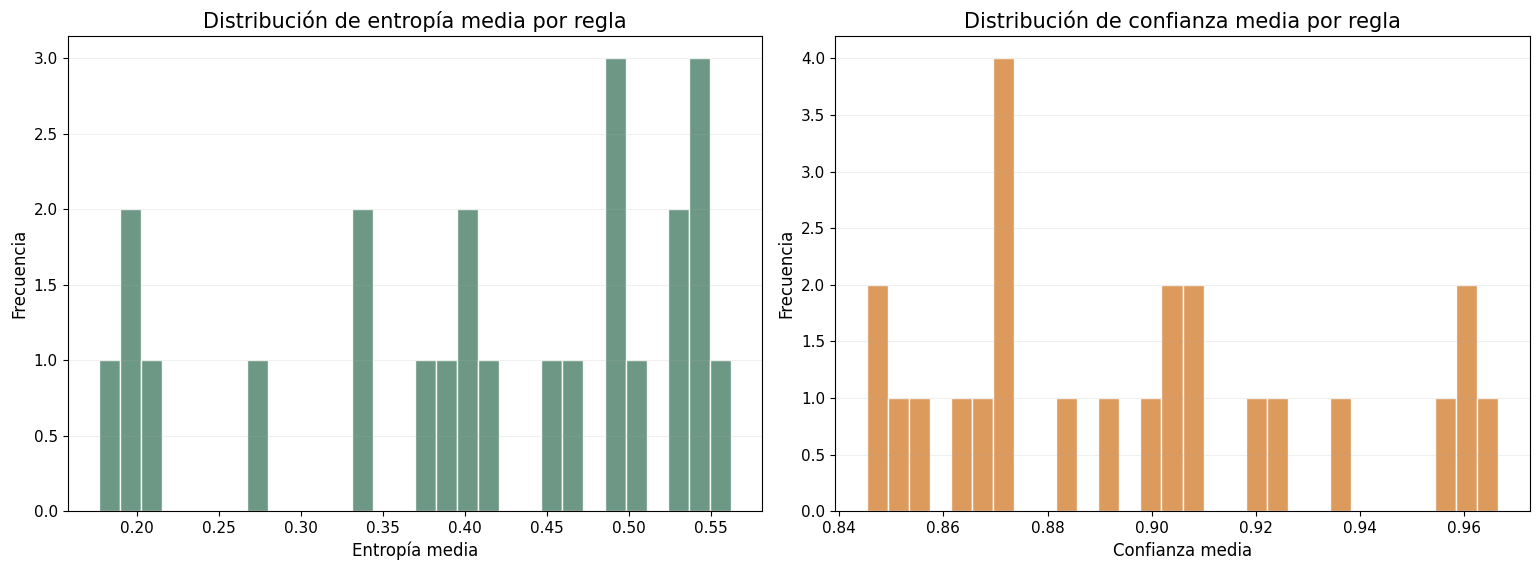

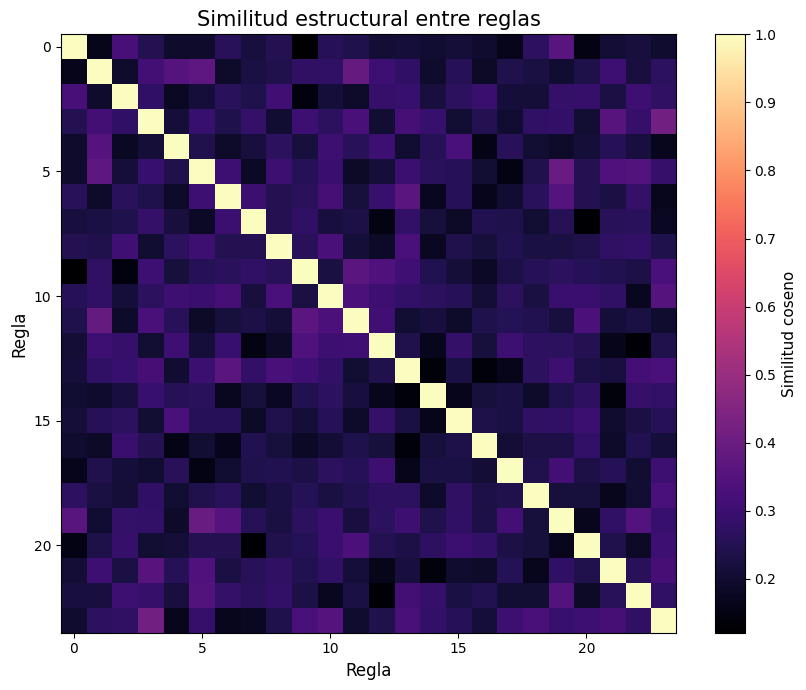

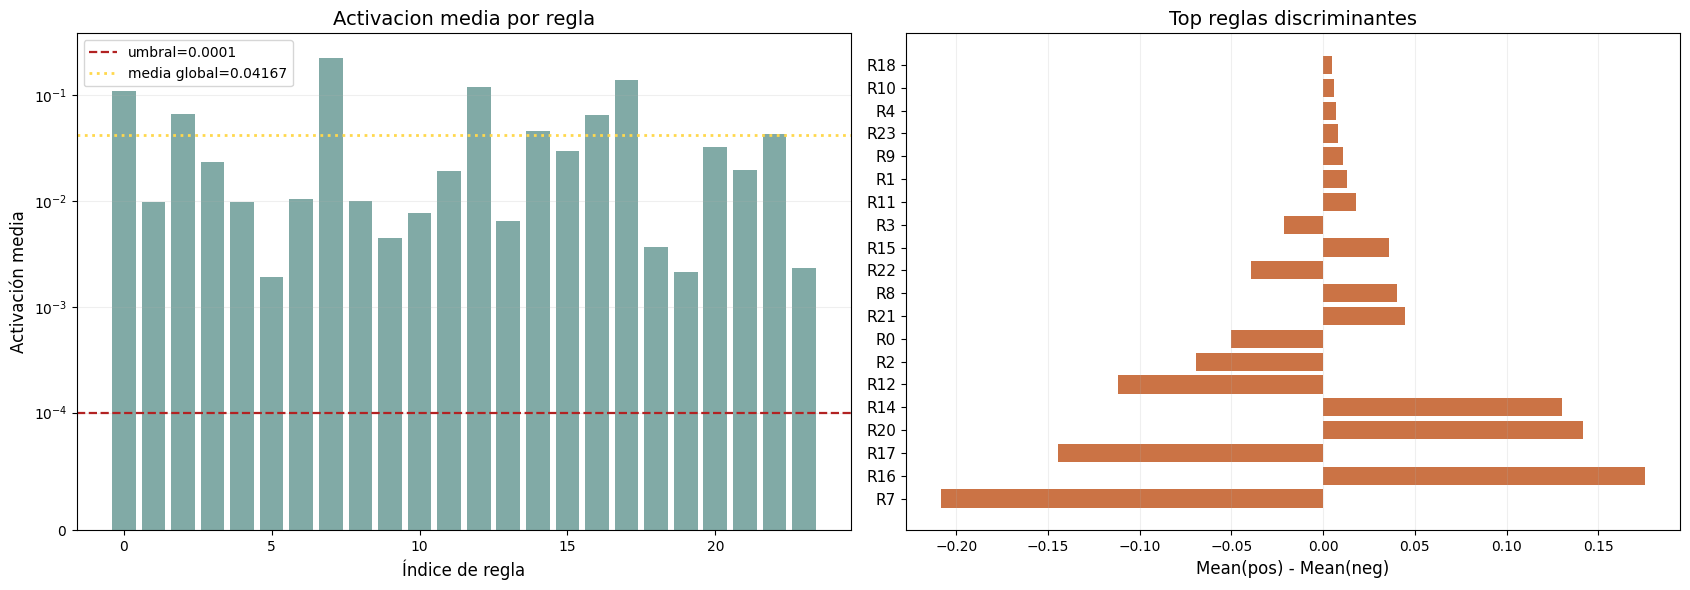

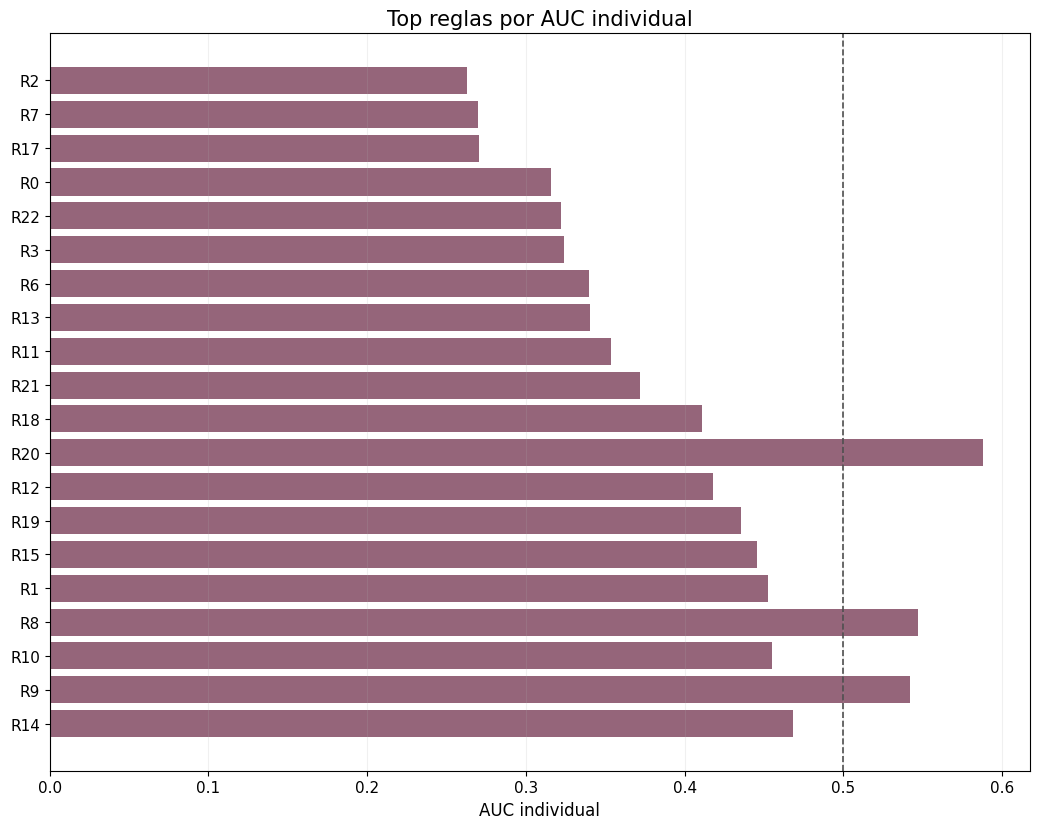

In [9]:
run_global_interpretability_pipeline(
    path_dataset="data/raw/interpretability_val.csv",
    path_config="config/config.yaml",
    make_plots=True,
    dead_rule_threshold=1e-4
)

### Coherencia XAI

In [10]:
coherence_validation = evaluate_xai_coherence_by_confusion_group(
    path_config="config/config.yaml",
    path_dataset="data/raw/interpretability_val.csv",
    n_per_group="all",
    verbose=True,
    evaluate_only_fault_windows=True,
    include_empty_groups=False,
)

metric_cols = _coherence_metric_columns()

def _show_coherence_table(df: pd.DataFrame, columns: List[str]) -> None:
    display(df[columns].round(3))

_show_coherence_table(
    coherence_validation["coherence_macro_by_group"],
    ["N_cases", "N_fault_types"] + metric_cols,
)

_show_coherence_table(
    coherence_validation["coherence_by_fault"],
    ["N_cases"] + metric_cols,
)

_show_coherence_table(
    coherence_validation["coherence_macro_by_fault_only"],
    ["N_cases"] + metric_cols,
)

2026-07-09 18:55:34 - Cargando datos desde data/raw/interpretability_val.csv


2026-07-09 18:55:36 - Dataset cargado: 900000 filas x 16 columnas
2026-07-09 18:55:36 - Validacion de datos de entrada superada correctamente: variables presentes, tipo numerico, sin columnas completamente nulas, cantidad suficiente de datos.
2026-07-09 18:55:36 - ==============================
2026-07-09 18:55:48 - Umbral cargado: 0.410 (fuente=best_threshold)
2026-07-09 18:55:48 - ==============================
2026-07-09 18:55:48 - Arquitectura configurada:
2026-07-09 18:55:48 - ==============================
2026-07-09 18:55:48 - Rama DL: Input (180, 13) -> LSTM(hidden=32, layers=2, bidir=True) -> Atención -> Embedding 32 -> Head anom 1
2026-07-09 18:55:48 - Rama Fuzzy: Input 65 -> Membership (5 por feature) -> Reglas (24) -> Output anom 1
2026-07-09 18:55:48 - Mezcla tardía: lambda_anom=0.700
2026-07-09 18:55:48 - Modelo cargado desde models/artifacts/best_dnf_model.pt
2026-07-09 18:55:48 - Archivo CSV de background detectado en: data/raw/xai_background.csv
2026-07-09 18:55:48 - V

,N_cases,N_fault_types,Neuro-difusa_Jaccard,Neuro-difusa_MRR,LSTM-SHAP_Jaccard,LSTM-SHAP_MRR
Group,,,,,,
FN,84,8,0.248,0.555,0.517,0.707
TP,1019,8,0.250,0.515,0.526,0.819


N_cases  \
Group Fault_key                  Affected_variables_count            
FN    AISLAMIENTO_DEGRADADO      5                              11   
      REFRACTARIO_EROSIONADO     6                               9   
      RESISTENCIA_DEGRADADA      6                               3   
      SENSOR_DESCALIBRADO_DRIFT  2                              11   
      SENSOR_DESCALIBRADO_FROZEN 3                               2   
      SENSOR_DESCALIBRADO_SPIKE  1                              27   
      VALVULA_OBSTRUIDA          8                              12   
      VENTILADOR_DEFECTUOSO      8                               9   
TP    AISLAMIENTO_DEGRADADO      5                             195   
      REFRACTARIO_EROSIONADO     6                             183   
      RESISTENCIA_DEGRADADA      6                             149   
      SENSOR_DESCALIBRADO_DRIFT  2                              52   
      SENSOR_DESCALIBRADO_FROZEN 3                              42   
      SENSOR_DESCALIBRADO_SPIKE  1                              45   
      VALVULA_OBSTRUIDA          8                             168   
      VENTILADOR_DEFECTUOSO      8                             185   

                                                           Neuro-difusa_Jaccard  \
Group Fault_key                  Affected_variables_count                         
FN    AISLAMIENTO_DEGRADADO      5                                        0.223   
      REFRACTARIO_EROSIONADO     6                                        0.262   
      RESISTENCIA_DEGRADADA      6                                        0.344   
      SENSOR_DESCALIBRADO_DRIFT  2                                        0.061   
      SENSOR_DESCALIBRADO_FROZEN 3                                        0.100   
      SENSOR_DESCALIBRADO_SPIKE  1                                        0.000   
      VALVULA_OBSTRUIDA          8                                        0.500   
      VENTILADOR_DEFECTUOSO      8                                        0.494   
TP    AISLAMIENTO_DEGRADADO      5                                        0.274   
      REFRACTARIO_EROSIONADO     6                                        0.261   
      RESISTENCIA_DEGRADADA      6                                        0.293   
      SENSOR_DESCALIBRADO_DRIFT  2                                        0.058   
      SENSOR_DESCALIBRADO_FROZEN 3                                        0.098   
      SENSOR_DESCALIBRADO_SPIKE  1                                        0.067   
      VALVULA_OBSTRUIDA          8                                        0.467   
      VENTILADOR_DEFECTUOSO      8                                        0.484   

                                                           Neuro-difusa_MRR  \
Group Fault_key                  Affected_variables_count                     
FN    AISLAMIENTO_DEGRADADO      5                                    0.409   
      REFRACTARIO_EROSIONADO     6                                    0.778   
      RESISTENCIA_DEGRADADA      6                                    1.000   
      SENSOR_DESCALIBRADO_DRIFT  2                                    0.182   
      SENSOR_DESCALIBRADO_FROZEN 3                                    0.500   
      SENSOR_DESCALIBRADO_SPIKE  1                                    0.000   
      VALVULA_OBSTRUIDA          8                                    0.903   
      VENTILADOR_DEFECTUOSO      8                                    0.670   
TP    AISLAMIENTO_DEGRADADO      5                                    0.736   
      REFRACTARIO_EROSIONADO     6                                    0.584   
      RESISTENCIA_DEGRADADA      6                                    0.709   
      SENSOR_DESCALIBRADO_DRIFT  2                                    0.125   
      SENSOR_DESCALIBRADO_FROZEN 3                                    0.298   
      SENSOR_DESCALIBRADO_SPIKE  1                                    0.067   
      VALVULA_OBSTRUIDA          8     

,N_cases,Neuro-difusa_Jaccard,Neuro-difusa_MRR,LSTM-SHAP_Jaccard,LSTM-SHAP_MRR
Fault_key,,,,,
AISLAMIENTO_DEGRADADO,206,0.271,0.719,0.465,0.960
REFRACTARIO_EROSIONADO,192,0.261,0.593,0.501,0.783
RESISTENCIA_DEGRADADA,152,0.294,0.714,0.704,1.000
SENSOR_DESCALIBRADO_DRIFT,63,0.058,0.135,0.688,0.952
SENSOR_DESCALIBRADO_FROZEN,44,0.098,0.307,0.391,1.000
SENSOR_DESCALIBRADO_SPIKE,72,0.042,0.042,0.250,0.250
VALVULA_OBSTRUIDA,180,0.469,0.824,0.564,0.786
VENTILADOR_DEFECTUOSO,194,0.485,0.779,0.545,0.683


### Validación interpretabilidad local

In [11]:
local_validation = validate_local_pipeline_by_confusion_group(
    path_config = "config/config.yaml",
    path_dataset = "data/raw/interpretability_val.csv",
    n_per_group = "all", # número de muestras por grupo TP/TN/FP/FN para validar métricas de interpretabilidad y consistencia
    verbose = True,  
)

print_group_validation_summary(local_validation, top_k=5)

2026-07-09 19:25:46 - Cargando datos desde data/raw/interpretability_val.csv


2026-07-09 19:25:48 - Dataset cargado: 900000 filas x 16 columnas
2026-07-09 19:25:48 - Validacion de datos de entrada superada correctamente: variables presentes, tipo numerico, sin columnas completamente nulas, cantidad suficiente de datos.
2026-07-09 19:25:48 - ==============================
2026-07-09 19:25:59 - Umbral cargado: 0.410 (fuente=best_threshold)
2026-07-09 19:25:59 - ==============================
2026-07-09 19:25:59 - Arquitectura configurada:
2026-07-09 19:25:59 - ==============================
2026-07-09 19:25:59 - Rama DL: Input (180, 13) -> LSTM(hidden=32, layers=2, bidir=True) -> Atención -> Embedding 32 -> Head anom 1
2026-07-09 19:25:59 - Rama Fuzzy: Input 65 -> Membership (5 por feature) -> Reglas (24) -> Output anom 1
2026-07-09 19:25:59 - Mezcla tardía: lambda_anom=0.700
2026-07-09 19:25:59 - Modelo cargado desde models/artifacts/best_dnf_model.pt
2026-07-09 19:25:59 - Archivo CSV de background detectado en: data/raw/xai_background.csv
2026-07-09 19:25:59 - V

### Evaluación sistema de generación de acciones correctivas

In [12]:
ACTION_CONFIG = {
    "combustion_control_flujo": {
        "variables": ["flujo_gas", "posicion_valvula", "potencia_kw"],
        "actions": [
            "Verificar alimentación de gas y respuesta de la válvula de control.",
            "Comprobar restricciones en línea o desviaciones del lazo de control de caudal.",
        ],
    },
    "termico": {
        "variables": ["temp_zona1", "temp_zona2", "temp_zona3", "temp_salida_gases"],
        "actions": [
            "Revisar estabilidad térmica del horno y la respuesta del sistema de aporte energético.",
            "Comprobar coherencia entre potencia aplicada y evolución de temperaturas.",
        ],
    },
    "ventilacion_presion": {
        "variables": ["velocidad_ventilador", "presion_ventilacion", "presion_camara"],
        "actions": [
            "Inspeccionar ventilación y estado del actuador o ventilador.",
            "Comprobar si existen oscilaciones de control o respuesta lenta del sistema de aire.",
        ],
    },
}

MONITORING_ACTION_CONFIG = {
    "strong_margin": 0.25,
    "weak_margin": 0.15,
    "support_ratio_min": 0.75,
    "branch_gap_threshold": 0.25,
}

action_eval_report = evaluate_action_labeling_by_confusion_group(
    path_config = "config/config.yaml",
    path_dataset = "data/raw/actions_system_eval.csv",
    n_per_group = "all",   # número de muestras por grupo efectivo real (TP/TN/FP/FN) para evaluar el etiquetado y bloques de acción
    action_config = ACTION_CONFIG,
    top_blocks = 3,
    min_block_score = 0.10,
    max_actions = 4,
    # Parámetros de etiquetado interpretativo 
    corrective_actions_cfg = MONITORING_ACTION_CONFIG,
)

print_action_labeling_evaluation_summary(action_eval_report)

2026-07-09 22:47:03 - Cargando datos desde data/raw/actions_system_eval.csv


2026-07-09 22:47:04 - Dataset cargado: 300000 filas x 16 columnas
2026-07-09 22:47:04 - Validacion de datos de entrada superada correctamente: variables presentes, tipo numerico, sin columnas completamente nulas, cantidad suficiente de datos.
2026-07-09 22:47:04 - ==============================
2026-07-09 22:47:07 - Umbral cargado: 0.410 (fuente=best_threshold)
2026-07-09 22:47:07 - ==============================
2026-07-09 22:47:07 - Arquitectura configurada:
2026-07-09 22:47:07 - ==============================
2026-07-09 22:47:07 - Rama DL: Input (180, 13) -> LSTM(hidden=32, layers=2, bidir=True) -> Atención -> Embedding 32 -> Head anom 1
2026-07-09 22:47:07 - Rama Fuzzy: Input 65 -> Membership (5 por feature) -> Reglas (24) -> Output anom 1
2026-07-09 22:47:07 - Mezcla tardía: lambda_anom=0.700
2026-07-09 22:47:07 - Modelo cargado desde models/artifacts/best_dnf_model.pt
2026-07-09 22:47:07 - Archivo CSV de background detectado en: data/raw/xai_background.csv
2026-07-09 22:47:07 - V